libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


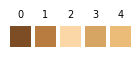

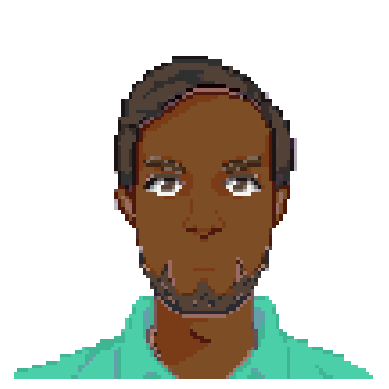

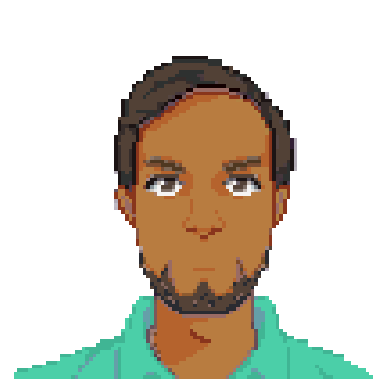

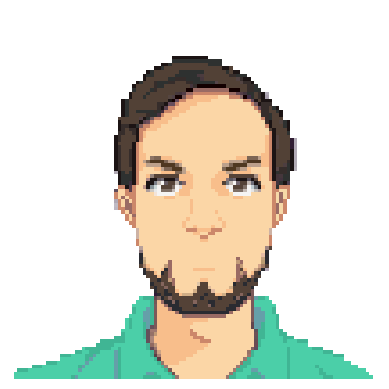

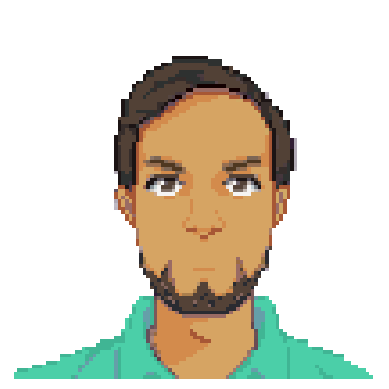

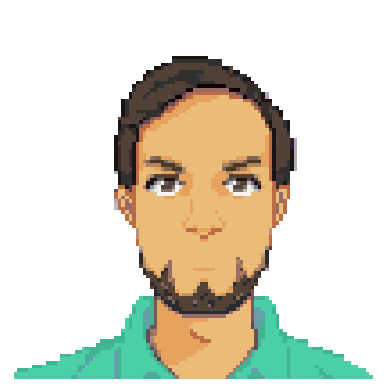

In [239]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

class recolourImage():
    def __init__(self):
        self.colourPaletter = []
        self.skin_colour = [14, 80, 250]
        self.new_skin_colour = [14, 80, 200]
        self.skin_colour_palette = []
        self.tol = 69

    def getImage(self, image_path):
        self.img = cv2.imread(image_path)

    def dispColourPalette(self, colour_palette):
        num_colours = len(colour_palette)
        # print(num_colours)
        # Display the colour palette
        plt.figure()
        cols = 20
        rows = math.ceil(num_colours/cols)
        for idx, col in enumerate(colour_palette):
            plt.subplot(rows, cols, idx+1)
            # convert to rgb
            colour =  cv2.cvtColor(np.uint8([[col]]), cv2.COLOR_HSV2RGB)[0, 0, :]
            plt.imshow([[colour]], extent=(0, 1, 0, 1))

            # if skin tone add a rectangle
            if col in self.skin_colour_palette:
                rect = patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='r', facecolor='none')
                plt.gca().add_patch(rect)

            plt.title(idx, fontsize=7)
            plt.axis('off')
    
    def showImg(self):
        # show image
        plt.figure()
        plt.imshow(cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
    
    def getColourPalette(self):
        # Convert the image to HSV color space
        hsv_image = cv2.cvtColor(self.img, cv2.COLOR_BGR2HSV)
        colours = set(tuple(pixel) for row in hsv_image for pixel in row)
        # Sort the colours set by Hue value
        self.colour_palette = sorted(colours, key=lambda x: x[0])
    
    def colour_distance(self, color1, color2):
        return np.linalg.norm(np.array(color1) - np.array(color2))
    
    def getSkinTone(self):
        self.skin_colour_palette = []
        # [colour_distance([14, 80, 250],col) for col in self.colour_palette]
        for col in self.colour_palette:
            # self.colour_distance(col,col)
            if self.colour_distance(self.skin_colour,col) < self.tol:
                self.skin_colour_palette.append(col)

    def dispChange(self):
        plt.figure(figsize=(1,2))
        plt.subplot(1, 2, 1)
        colour =  cv2.cvtColor(np.uint8([[self.skin_colour]]), cv2.COLOR_HSV2RGB)[0, 0, :]
        plt.imshow([[colour]], extent=(0, 1, 0, 1))
        plt.axis('off')
        plt.subplot(1, 2, 2)
        colour =  cv2.cvtColor(np.uint8([[self.new_skin_colour]]), cv2.COLOR_HSV2RGB)[0, 0, :]
        plt.imshow([[colour]], extent=(0, 1, 0, 1))
        plt.axis('off')

    def changeColuring(self):
        self.getColourPalette()
        self.getSkinTone()

        for idx, col in enumerate(self.colour_palette):
            if col in self.skin_colour_palette:
                mask = np.all(cv2.cvtColor(self.img, cv2.COLOR_BGR2HSV) == col, axis=-1)

                # Generate the new skin colour
                update = np.array(self.skin_colour) - np.array(col)
                new_col = self.new_skin_colour - update

                colour = cv2.cvtColor(np.uint8([[new_col]]), cv2.COLOR_HSV2BGR)[0, 0, :]
                self.img[mask] = colour


r = recolourImage()
# get the colours you want to use
r.getImage("skinColours.png")
r.getColourPalette()
r.dispColourPalette(r.colour_palette)
r.tol = 69

# calc size of figure
# plt.figure(figsize=(20,100))
# cols = 5
# rows = math.ceil(len(r.colour_palette)/cols)
for idx, skin_colour in enumerate(r.colour_palette):
    # make a new character
    r.new_skin_colour = skin_colour

    
    # get the image to replace
    r.getImage("Male103.png")

    r.changeColuring()

    plt.figure()
    plt.imshow(cv2.cvtColor(r.img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

plt.show()


/Users/albertborrellribas/Developer/python/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


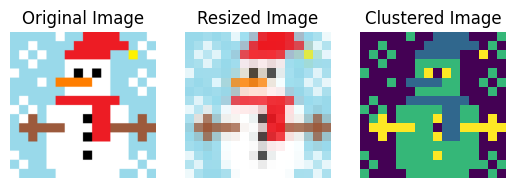

0 [163 216 229 255]
1 [234  58  53 255]
2 [241 242 243 255]
3 [144 108  82 255]


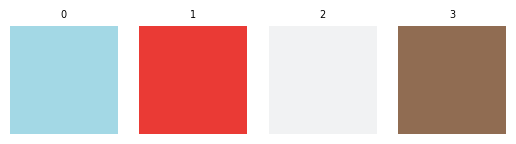

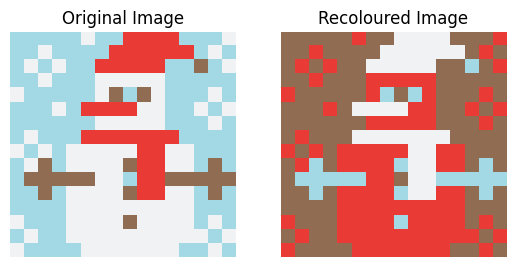

[[3 3 3 3 3 1 3 3 2 2 2 2 3 3 3 1]
 [3 3 1 3 3 3 3 2 2 2 2 2 2 3 1 3]
 [3 1 3 1 3 3 2 2 2 2 2 3 3 0 3 1]
 [3 3 1 3 3 3 1 1 1 1 1 3 3 3 3 3]
 [1 3 3 3 3 3 1 0 3 0 1 3 3 3 1 3]
 [3 3 3 1 3 2 2 2 2 1 1 3 3 1 3 1]
 [3 3 3 3 3 3 1 1 1 1 1 3 3 3 1 3]
 [3 1 3 3 3 2 2 2 2 2 2 2 3 3 3 3]
 [1 3 1 3 1 1 1 1 1 2 2 1 1 3 3 3]
 [3 1 0 3 1 1 1 1 0 2 2 1 1 3 0 3]
 [3 0 0 0 0 0 1 1 3 2 2 0 0 0 0 0]
 [3 3 0 3 1 1 1 1 0 2 2 1 1 3 0 3]
 [3 3 3 3 1 1 1 1 1 1 1 1 1 3 3 3]
 [1 3 3 3 1 1 1 1 0 1 1 1 1 3 1 3]
 [3 1 3 3 1 1 1 1 1 1 1 1 1 1 3 1]
 [1 3 3 3 3 1 1 1 1 1 1 1 3 3 1 3]]
(16, 16)


In [2]:
# pip install pillow scikit-learn
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

def quantize_colors(image_path, n, num_colours=3):
    # Open the image
    original_image = Image.open(image_path)

    # Check that the image is nxnx4
    if original_image.mode != 'RGBA':
        # change image to be nxnx4
        original_image = original_image.convert('RGBA')

    # Resize the image to n by n pixels
    img = original_image.resize((n, n))

    # Convert the image to a NumPy array
    img_array = np.array(img)

    # print(img_array)
    # print(img_array.shape)

    # reshape into pixel and it's values
    pixels = img_array.reshape((-1, 4))
    # print(img_array.shape)
    # print(img_array)
    # print(pixels.shape)

    # Apply k-means clustering to find representative colors
    kmeans = KMeans(n_clusters=num_colours, random_state=42)
    kmeans.fit(pixels)
    labels = kmeans.predict(pixels)

    # Get the cluster centers (representative colors)
    cluster_centers = kmeans.cluster_centers_.astype(int)

    # print(labels.shape)
    # Reshape the labels back to the original image dimensions
    clustered_image = labels.reshape((n, n))

    # Display the original image
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(original_image)
    plt.axis('off')
    # Display the resized image
    plt.subplot(1, 3, 2)
    plt.title("Resized Image")
    plt.imshow(img)
    plt.axis('off')
    # Display the clustered image
    plt.subplot(1, 3, 3)
    plt.title("Clustered Image")
    plt.imshow(clustered_image, cmap='viridis')  # Change colour map if needed
    plt.axis('off')
    # Show the plots
    plt.show()

    # Display the colour palette
    plt.figure()
    for idx, colour in enumerate(cluster_centers):
        plt.subplot(1, num_colours, idx+1)
        plt.imshow([[colour]], extent=(0, 1, 0, 1))
        plt.title(idx, fontsize=7)
        print(idx, colour)
        plt.axis('off')
    plt.show()
    # Display each color as subplots
    plt.figure()

    return clustered_image, cluster_centers

def recolour(surf_map, keys, cols):
    # colour map
    colours = [(0, 0, 0), (1, 1, 1), (1, 0, 0), (0.5, 0.5, 0.5)]

    # custom_cmap = ListedColormap(colours)
    custom_cmap = ListedColormap(cols) # using the provided colours
    # custom_cmap = "plasma"

    # Display the original image
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(surf_map, cmap=custom_cmap)
    plt.axis('off')
    for i in range(surf_map.shape[0]):
        for j in range(surf_map.shape[1]):
            # check that the value exist in the key
            if surf_map[i][j] in keys:
                surf_map[i][j] = keys[surf_map[i][j]]
            else:
                # print(f"{surf_map[i][j]} not in the keys {keys} given")
                x = 1
    
    # Display the recoloured image
    plt.subplot(1, 2, 2)
    plt.title("Recoloured Image")
    plt.imshow(surf_map, cmap=custom_cmap)
    plt.axis('off')
    # Show the plots
    plt.show()



result_array, colours = quantize_colors("image2.png", 16, 4)

wrap = {0: 3, 1: 2, 2:1, 3:0}
recolour(result_array, wrap, colours/255)
print(result_array)
print(result_array.shape)

